In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

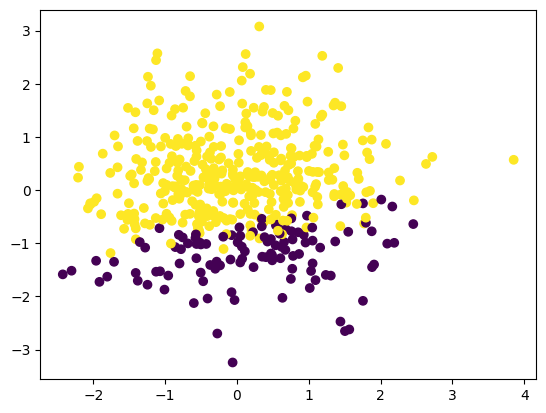

In [4]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [101]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


50. Training loss: 0.5104284745369558, Val loss:0.5096830037085236
100. Training loss: 0.4755721881536631, Val loss:0.4776817269491726
150. Training loss: 0.446629489007344, Val loss:0.4511228642557118
200. Training loss: 0.42244655192188213, Val loss:0.42893988060421745
250. Training loss: 0.4020880450778014, Val loss:0.41026719448247295
300. Training loss: 0.3848069814383682, Val loss:0.3944142692703644
350. Training loss: 0.37001160745178474, Val loss:0.38083538709019576
400. Training loss: 0.35723469403555763, Val loss:0.36910084303078516
450. Training loss: 0.34610731256181787, Val loss:0.35887216578155273
500. Training loss: 0.3363374478661988, Val loss:0.34988196189733695
550. Training loss: 0.32769302298007397, Val loss:0.3419180191885935
600. Training loss: 0.31998864035016356, Val loss:0.33481097487299777
650. Training loss: 0.3130753186253522, Val loss:0.32842482578799465
700. Training loss: 0.30683258165267435, Val loss:0.3226496464272412
750. Training loss: 0.3011623661001

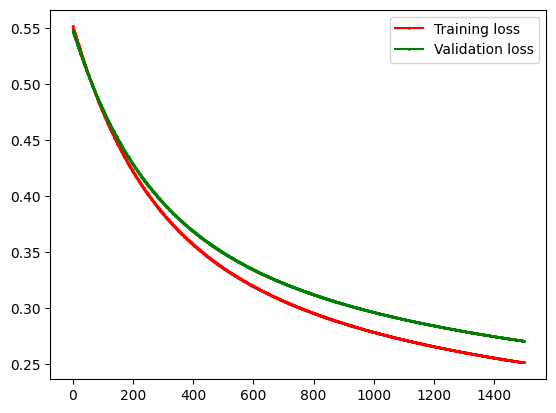

,dim,5
,is_reg,False
,loss_fn,<function log...00205D782FEC0>
,grad_fn,<function log...00205D78A40E0>
,act_fn,<function sig...00205C4D5F420>
,lr,0.1
,reg_type,''
,reg_lambda,0
,n_iteration,50
,val_ratio,0.2
,random_state,None


In [108]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =1500,val_ratio=0.2)

In [109]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9231
Precision : 0.9360
Recall    : 0.9244
F1-score  : 0.9302


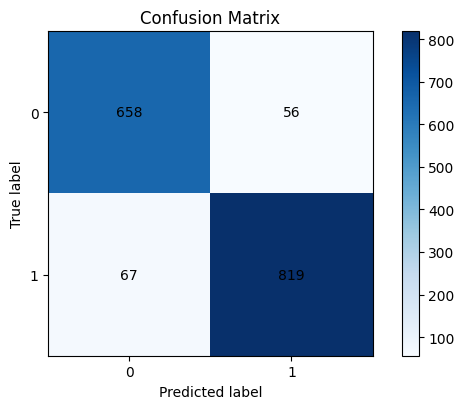

{'Accuracy': 0.923125,
 'Precision': 0.936,
 'Recall': 0.9243792325056434,
 'F1-score': 0.9301533219761499}

In [110]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

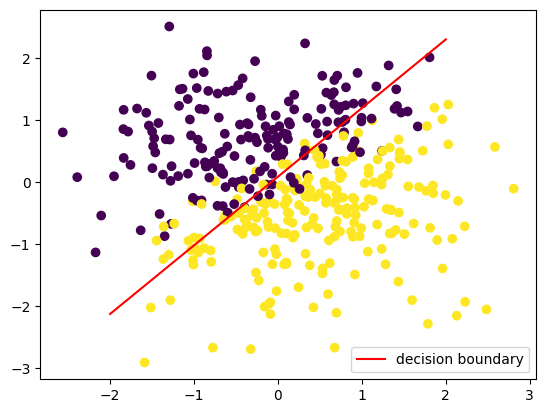

In [9]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()